   Pos        A        C        G        T     H(i)    IC(i)
     1   0.1058   0.5865   0.1058   0.2019   1.6031   0.3969
     2   0.7788   0.2019   0.0096   0.0096   0.8758   1.1242
     3   0.1058   0.1058   0.7788   0.0096   1.0309   0.9691
     4   0.0096   0.0096   0.9712   0.0096   0.2343   1.7657
     5   0.0096   0.0096   0.0096   0.9712   0.2343   1.7657
     6   0.2019   0.5865   0.0096   0.2019   1.4480   0.5520
     7   0.6827   0.0096   0.2981   0.0096   1.0253   0.9747
     8   0.2019   0.0096   0.7788   0.0096   0.8758   1.1242
     9   0.1058   0.7788   0.0096   0.1058   1.0309   0.9691
  Итого                                                9.6417 суммарный IC
Кор-позиции (IC ≥ 1.5): [4, 5]
Вариабельные (IC < 1.5): [1, 2, 3, 6, 7, 8, 9]

  pos1: IC=0.397  H=1.603    вар  (доминант: C = 0.587)
  pos2: IC=1.124  H=0.876    вар  (доминант: A = 0.779)
  pos3: IC=0.969  H=1.031    вар  (доминант: G = 0.779)
  pos4: IC=1.766  H=0.234  ★ КОР  (доминант: G = 0.971)
  pos5: IC=1

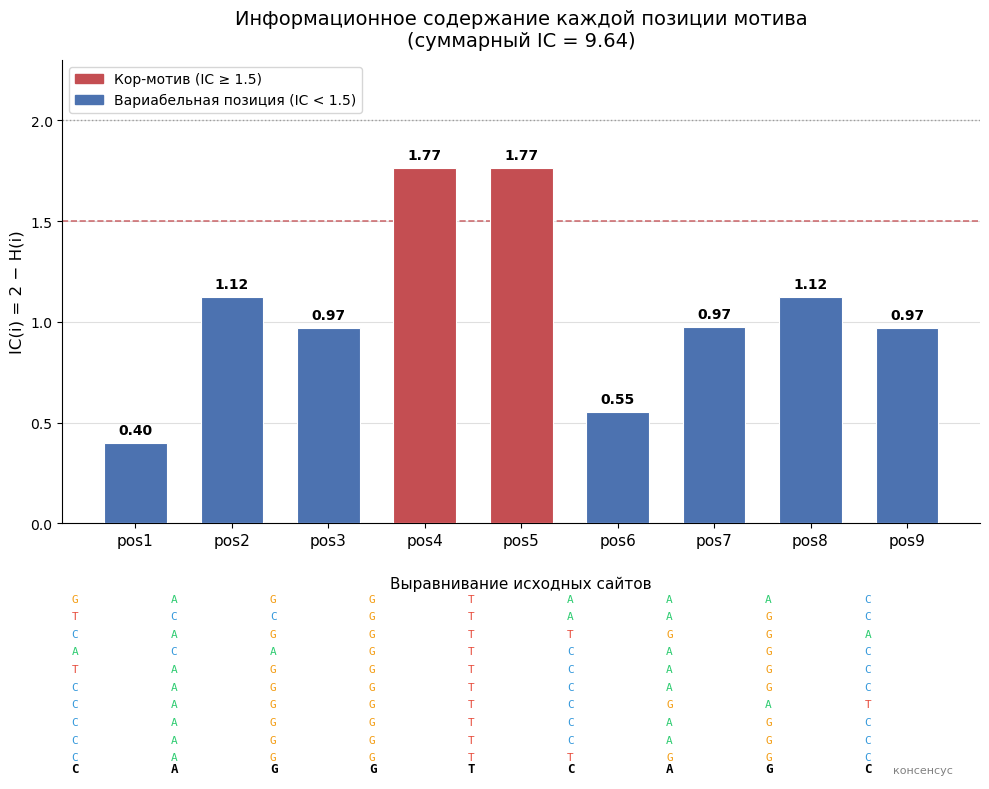

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# PPM 
NUCLEOTIDES = ["A", "C", "G", "T"]
BG_PROBS = np.array([0.295, 0.205, 0.205, 0.295])
sites = ["GAGGTAAAC", "TCCGTAAGC", "CAGGTTGGA", "ACAGTCAGC", "TAGGTCAGC","CAGGTCAGC", "CAGGTCGAT", "CAGGTCAGC", "CAGGTCAGC", "CAGGTTGGC",]
L, N, alpha = 9, 10, 0.1

pfm = np.zeros((4, L), dtype=float)
for site in sites:
    for pos, nuc in enumerate(site):
        pfm[NUCLEOTIDES.index(nuc), pos] += 1
ppm = (pfm + alpha) / (N + 4 * alpha)  

# энтропия Шеннона 
def shannon_entropy(ppm: np.ndarray) -> np.ndarray:
    log2p = np.where(ppm > 0, np.log2(ppm), 0.0)
    return -(ppm * log2p).sum(axis=0)   

H = shannon_entropy(ppm)
IC = 2.0 - H
print(f"  {'Pos':>4}  {'A':>7}  {'C':>7}  {'G':>7}  {'T':>7}  {'H(i)':>7}  {'IC(i)':>7}")
for i in range(L):
    row = (f"  {i+1:>4}  "
           + "  ".join(f"{ppm[j,i]:>7.4f}" for j in range(4))
           + f"  {H[i]:>7.4f}  {IC[i]:>7.4f}")
    print(row)
print(f"  {'Итого':>4}  {'':>7}  {'':>7}  {'':>7}  {'':>7}  " 
      f"{'':>7}  {IC.sum():>7.4f} суммарный IC")

CORE_THRESHOLD = 1.5 
positions = np.arange(1, L + 1)
colors = ["#C44E52" if ic >= CORE_THRESHOLD else "#4C72B0" for ic in IC]
fig, axes = plt.subplots(2, 1, figsize=(10, 8), gridspec_kw={"height_ratios": [2.5, 1]})
ax = axes[0]
bars = ax.bar(positions, IC, color=colors, edgecolor="white", linewidth=0.8, width=0.65, zorder=3)

for bar, ic_val in zip(bars, IC):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.03, f"{ic_val:.2f}", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax.axhline(2.0, color="gray", linewidth=1, linestyle=":", alpha=0.7, label="IC = 2 ")
ax.axhline(CORE_THRESHOLD, color="#C44E52", linewidth=1.2, linestyle="--", alpha=0.8, label=f"Порог кор-мотива")

core_patch = mpatches.Patch(color="#C44E52", label=f"Кор-мотив (IC ≥ {CORE_THRESHOLD})")
var_patch  = mpatches.Patch(color="#4C72B0", label=f"Вариабельная позиция (IC < {CORE_THRESHOLD})")
ax.legend(handles=[core_patch, var_patch], fontsize=10, loc="upper left")
ax.set_xticks(positions)
ax.set_xticklabels([f"pos{i}" for i in positions], fontsize=11)
ax.set_ylabel("IC(i) = 2 − H(i)", fontsize=12)
ax.set_ylim(0, 2.3)
ax.set_title("Информационное содержание каждой позиции мотива\n" f"(суммарный IC = {IC.sum():.2f})", fontsize=14, pad=10)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.yaxis.grid(True, alpha=0.4, zorder=0)
ax.set_axisbelow(True)
ax2 = axes[1]
ax2.axis("off")

consensus = "".join(NUCLEOTIDES[pfm[:, i].argmax()] for i in range(L))
nuc_colors_map = {"A": "#2ecc71", "C": "#3498db", "G": "#f39c12", "T": "#e74c3c"}
for row_idx, site in enumerate(sites):
    for col_idx, nuc in enumerate(site):
        ax2.text(col_idx * 0.108 + 0.01, 1 - row_idx * 0.095, nuc, transform=ax2.transAxes, fontsize=8, fontfamily="monospace", color=nuc_colors_map[nuc], va="top")

for col_idx, nuc in enumerate(consensus):
    ax2.text(col_idx * 0.108 + 0.01, 0.02, nuc, transform=ax2.transAxes, fontsize=9, fontfamily="monospace", fontweight="bold", color="black", va="bottom")

ax2.text(0.97, 0.02, "консенсус", transform=ax2.transAxes, fontsize=8, ha="right", color="gray", va="bottom")
ax2.set_title("Выравнивание исходных сайтов", fontsize=11, pad=4)
plt.tight_layout(h_pad=2)

core_positions = [i+1 for i, ic in enumerate(IC) if ic >= CORE_THRESHOLD]
var_positions  = [i+1 for i, ic in enumerate(IC) if ic < CORE_THRESHOLD]
print(f"Кор-позиции (IC ≥ {CORE_THRESHOLD}): {core_positions}")
print(f"Вариабельные (IC < {CORE_THRESHOLD}): {var_positions}")
print()
for i in range(L):
    dominant = NUCLEOTIDES[ppm[:, i].argmax()]
    flag = "★ КОР" if IC[i] >= CORE_THRESHOLD else "  вар"
    print(f"  pos{i+1}: IC={IC[i]:.3f}  H={H[i]:.3f}  {flag}"
          f"  (доминант: {dominant} = {ppm[NUCLEOTIDES.index(dominant),i]:.3f})")
print(f"\n  Кор-мотив: {''.join(consensus[i-1] for i in core_positions)}"
      f"на позициях {core_positions}")
print(f"Полный консенсус: {consensus}")

'''
Позиции 4 и 5 (динуклеотид GT) имеют IC = 1.77 — кор-мотив, встречается в 10/10 сайтах. 
Остальные позиции вариабельны (IC < 1.2): фактор допускает замены, не нарушающие связывания. 
Суммарный IC мотива = 9.64 из максимальных 18 — мотив достаточно специфичен. 
Результат совпадает с визуальным осмотром выравнивания: столбцы 4 и 5 однородны по цвету, остальные пёстрые.
'''